### [__Making PR and ROC Plots__](https://plotly.com/python/roc-and-pr-curves/)
--- 
* y_true will either be 0 or 1 which corresponds to False and True
     * ipTM score will be used to determine this 
        * ipTM ≥ 0.6 will be True/1
        * ipTM < 0.6 will be False/0
        * Will double check ipTM gold standard 
* y_score will be the STRING scores ≥ 400 (True positives)
    * Check with gold standard

[__Precision Recall Curve__](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_recall_curve.html)

Variable will be:
* precision
* recall
* thresholds
* auc_pr

will write: 

    `precision, reall, thresholds = precision_recall_curve(y_true, y_score)`

    `auc_pr= average_percision_score(y_true, y_score)`

[__Receiver Operating Characteristic__](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html)

Varibles will be:
* fpr
* tpr
* thresholds
* auc_score

will write:

    `fpr, tpr, thresholds = roc_curve(y_true, y_score)
    `auc_score = roc_auc_score(y_true, y_score)`

In [44]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np

In [62]:
## load csv `graph`
final_comp = pl.scan_csv("final_comp.csv")

final_comp = final_comp.with_columns(
    (pl.col("chain_pair_iptm_mean") >= 0.6).cast(pl.Int64).alias("true_pos")
)

final_comp_sig = final_comp.filter(
    (pl.col("combined_score").is_not_null()) & 
    (pl.col("combined_score").cast(pl.Int32) >= 400)
    # Removed the >= 0.6 filter so negative cases remain in the dataset
)

In [64]:
final_comp_sig.collect().head(-5)

protein1,protein2,chain_pair_iptm_best,chain_pair_iptm_mean,chain_pair_iptm_best_corrected,chain_pair_iptm_mean_corrected,string_id1,string_id2,combined_score,true_pos
str,str,f64,f64,f64,f64,str,str,str,i64
"""p36517""","""q02555""",0.09,0.09,0.004051,0.003804,"""4932.YLR439W""","""4932.YMR239C""","""513""",0
"""p36520""","""q04598""",0.07,0.064,0.017351,0.011125,"""4932.YNL284C""","""4932.YDR115W""","""963""",0
"""p33322""","""q03940""",0.1,0.102,0.002194,0.00394,"""4932.YLR175W""","""4932.YDR190C""","""791""",0
"""p32462""","""q03281""",0.56,0.56,0.451348,0.451087,"""4932.YNL280C""","""4932.YDR458C""","""420""",0
"""p36049""","""p38779""",0.1,0.108,0.013021,0.020773,"""4932.YKL172W""","""4932.YHR052W""","""994""",0
…,…,…,…,…,…,…,…,…,…
"""p13517""","""p36224""",0.08,0.08,0.004862,0.004622,"""4932.YIL034C""","""4932.YMR294W""","""792""",0
"""p36049""","""q04660""",0.2,0.19,0.082638,0.07237,"""4932.YKL172W""","""4932.YMR049C""","""996""",0
"""p25443""","""q12672""",0.08,0.076,0.028769,0.024544,"""4932.YGL123W""","""4932.YPL079W""","""728""",0


In [65]:
# Setting up y_true and y_score

y_score = (
    final_comp_sig
    .filter(pl.col("combined_score").cast(pl.Int32) >= 400)
    .select(pl.col("combined_score").cast(pl.Int32))
    .collect()
    .to_numpy()
    .flatten()
)
y_true = final_comp_sig.select(pl.col("true_pos")).collect().to_numpy().flatten()

Precision Recall

In [ ]:
# %pip install plotly.express
import plotly.express as px
from sklearn.metrics import precision_recall_curve, auc, average_precision_score

precision, recall, thresholds = precision_recall_curve(y_true, y_score)
pr_auc = auc(recall, precision)

In [75]:
#ploting
fig = px.area(
    x=recall, y=precision,
    title=f'Precision-Recall Curve (AUC={auc(recall, precision):.4f})',
    labels=dict(x='Recall', y='Precision'),
    width=700, height=500
)
fig.add_shape(
    type='line', line=dict(dash='dash'),
    x0=0, x1=1, y0=1, y1=0
)
fig.update_yaxes(scaleanchor="x", scaleratio=1)
fig.update_xaxes(constrain='domain')

fig.show()

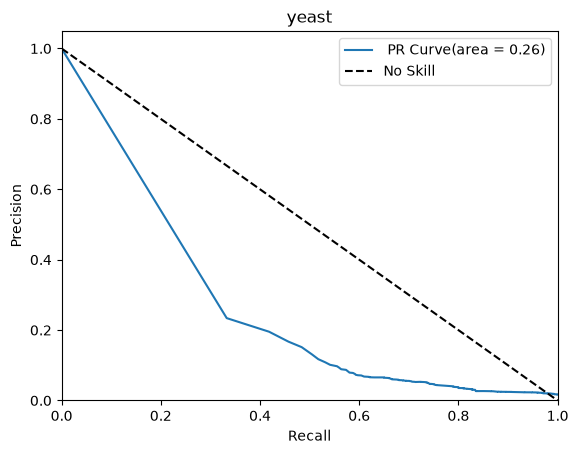

In [84]:
plt.figure()  
plt.plot(recall, precision, label=' PR Curve(area = %0.2f)' % pr_auc)
plt.plot([0, 1], [1, 0], 'k--', label='No Skill')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('yeast')
plt.legend()
plt.show()

ROC

In [69]:
from sklearn.metrics import roc_curve, auc, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_true, y_score)
auc_score = roc_auc_score(y_true, y_score)
roc_auc = auc(fpr, tpr)

In [74]:
fig = px.area(
    x=fpr, y=tpr,
    title=f'ROC Curve (AUC={auc(fpr, tpr):.4f})',
    labels=dict(x='False Positive Rate', y='True Positive Rate'),
    width=700, height=500
)
fig.add_shape(
    type='line', line=dict(dash='dash'),
    x0=0, x1=1, y0=0, y1=1
)

fig.update_yaxes(scaleanchor="x", scaleratio=1)
fig.update_xaxes(constrain='domain')
fig.show()

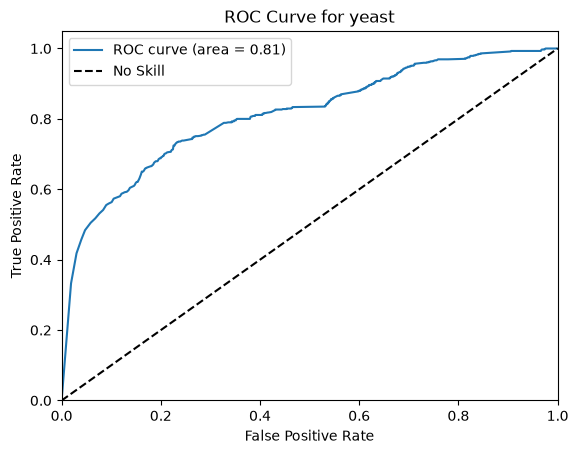

In [77]:
plt.figure()  
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--', label='No Skill')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for yeast')
plt.legend()
plt.show()

Side-by-side comparrison

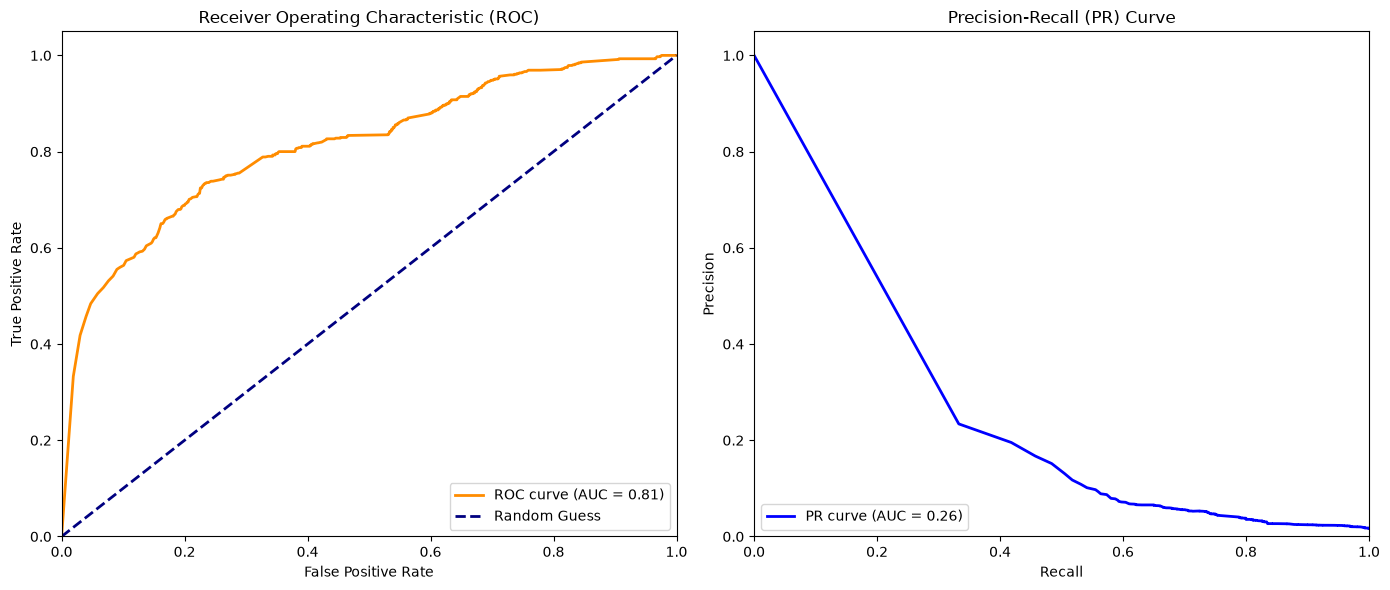

In [85]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ROC Curve Plot
ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')
ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('Receiver Operating Characteristic (ROC)')
ax1.legend(loc="lower right")

# PR Curve Plot
ax2.plot(recall, precision, color='blue', lw=2, label=f'PR curve (AUC = {pr_auc:.2f})')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall (PR) Curve')
ax2.legend(loc="lower left")

plt.tight_layout()
plt.show()